# 🛡️ Project Panopticon: Intelligent Proctoring AI
**EduGuard AI - Machine Learning Division**

**Intern Name:** `[Sai Vikas G V]`  
**Date:** `[16 August 2026]`

---

### 📖 Executive Summary
Welcome to EduGuard AI. Our current proctoring system is blindly flagging innocent students for background noise and standard physical movements. Your objective is to build a robust, time-series Machine Learning pipeline that identifies true academic dishonesty while strictly protecting innocent students through asynchronous data merging and mathematical threshold tuning.

### 🗺️ Project Roadmap
1. **Data Ingestion:** Upload and parse asynchronous telemetry logs.
2. **Temporal Alignment:** Merge video and system logs using `merge_asof`.
3. **Signal Processing:** Impute missing data and engineer rolling windows.
4. **Classification:** Train an imbalanced-weighted predictive model.
5. **Ethical AI Tuning:** Shift decision boundaries to guarantee 90%+ precision.

## 🎯 Project Objective

The objective of Project Panopticon is to develop an intelligent machine learning pipeline for detecting suspicious behavior during online examinations.

The system combines video telemetry and computer system events using asynchronous time-series alignment. Missing sensor data is handled through appropriate data-cleaning techniques, while rolling-window features are used to reduce the effect of short-term noise.

A Random Forest classification model is then trained to identify potentially suspicious behavior. The final decision is based on predicted probabilities and a high decision threshold to prioritize precision and minimize false accusations against innocent students.

## 📂 Dataset Description

This project uses two asynchronous time-series datasets:

### 1. Video Telemetry
The video telemetry dataset contains regularly recorded sensor information from the student's examination session, including:

- `timestamp` — Time of the recorded observation
- `eye_gaze_angle` — Eye-gaze measurement
- `audio_db` — Background audio level

### 2. System Events
The system events dataset records computer-related events when they occur, including:

- `timestamp` — Time at which the event occurred
- `tab_switches` — Recorded tab-switch activity
- `is_cheating` — Target label indicating suspicious/cheating behavior

### Data Alignment

The two datasets have different recording frequencies. Video telemetry is recorded regularly, while system events occur only when an event happens.

Therefore, a standard database-style merge is not appropriate. The datasets are aligned using Pandas `merge_asof()` with a backward-direction time match so that system events are associated with the appropriate video telemetry observation.

This preserves the examination timeline while combining information from both data sources.

In [1]:
# ==========================================
# 0. IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve

# Set visualization styles
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


---
## Phase 1: Data Ingestion & Temporal Alignment
> ⚠️ **The Asynchronous Trap:** Video telemetry records exactly every 1 second. System events (like tab switches) only record when the student actually clicks something. You cannot use a standard `pd.merge()`.

**Instructions:**
1. Upload the `video_telemetry.csv` and `system_events.csv` files.
2. Convert the timestamp columns to datetime objects.
3. Sort the dataframes and merge them using Pandas `merge_asof`.

In [2]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# ==========================================
# 1A. UPLOAD DATASETS (Google Colab Only)
# ==========================================
# If running locally, you can comment this block out.
try:
    from google.colab import files
    print("📂 Please upload 'video_telemetry.csv' and 'system_events.csv'...")
    uploaded = files.upload()
except ImportError:
    print("💻 Running locally. Ensure CSV files are in the same directory.")

# ==========================================
# 1B. LOAD AND PARSE DATA
# ==========================================
# TODO: Read the CSV files into pandas dataframes
video_df = pd.read_csv("video_telemetry (1) (1).csv")
sys_df = pd.read_csv("system_events (1) (1).csv")

# TODO: Convert 'timestamp' columns to pd.to_datetime()
video_df["timestamp"] = pd.to_datetime(video_df["timestamp"])
sys_df["timestamp"] = pd.to_datetime(sys_df["timestamp"])

# TODO: Sort BOTH dataframes by the 'timestamp' column
video_df = video_df.sort_values("timestamp").reset_index(drop=True)
sys_df = sys_df.sort_values("timestamp").reset_index(drop=True)

# ==========================================
# 1C. ASYNCHRONOUS MERGE
# ==========================================
# TODO: Use pd.merge_asof() to align sys_df into video_df to the nearest backward second
merged_df = pd.merge_asof(
    video_df,
    sys_df,
    on="timestamp",
    direction="backward"
)

merged_df.head()

💻 Running locally. Ensure CSV files are in the same directory.


,timestamp,eye_gaze_angle,audio_db,tab_switches,is_cheating
0,2023-12-01 08:00:00,2.560857,36.553781,NaN,NaN
1,2023-12-01 08:00:01,10.177137,39.102627,NaN,NaN
2,2023-12-01 08:00:02,5.761714,31.228565,NaN,NaN
3,2023-12-01 08:00:03,9.787105,34.051405,NaN,NaN
4,2023-12-01 08:00:04,4.572665,35.245018,NaN,NaN


In [4]:
print("Video data shape:", video_df.shape)
print("System events shape:", sys_df.shape)
print("Merged data shape:", merged_df.shape)

print("\nMerged columns:")
print(merged_df.columns.tolist())

print("\nMissing values:")
print(merged_df.isna().sum())

Video data shape: (10000, 3)
System events shape: (167, 3)
Merged data shape: (10000, 5)

Merged columns:
['timestamp', 'eye_gaze_angle', 'audio_db', 'tab_switches', 'is_cheating']

Missing values:
timestamp           0
eye_gaze_angle    732
audio_db          732
tab_switches       33
is_cheating        33
dtype: int64


In [5]:
print("Missing values before cleaning:")
print(merged_df.isna().sum())

Missing values before cleaning:
timestamp           0
eye_gaze_angle    732
audio_db          732
tab_switches       33
is_cheating        33
dtype: int64


In [6]:
merged_df["eye_gaze_angle"] = merged_df["eye_gaze_angle"].ffill()

print("Missing eye_gaze_angle values:",
      merged_df["eye_gaze_angle"].isna().sum())

Missing eye_gaze_angle values: 0


In [7]:
merged_df["audio_db"] = merged_df["audio_db"].interpolate()

print("Missing audio_db values:",
      merged_df["audio_db"].isna().sum())

Missing audio_db values: 0


In [8]:
merged_df["tab_switches"] = merged_df["tab_switches"].fillna(0)
merged_df["is_cheating"] = merged_df["is_cheating"].fillna(0)

print("Missing tab_switches:",
      merged_df["tab_switches"].isna().sum())

print("Missing is_cheating:",
      merged_df["is_cheating"].isna().sum())

Missing tab_switches: 0
Missing is_cheating: 0


In [9]:
merged_df["gaze_rolling_10s"] = (
    merged_df["eye_gaze_angle"]
    .rolling(window=10, min_periods=1)
    .mean()
)

merged_df["audio_rolling_10s"] = (
    merged_df["audio_db"]
    .rolling(window=10, min_periods=1)
    .mean()
)

print(merged_df[
    ["timestamp", "eye_gaze_angle", "gaze_rolling_10s",
     "audio_db", "audio_rolling_10s"]
].head(15))

             timestamp  eye_gaze_angle  gaze_rolling_10s   audio_db  \
0  2023-12-01 08:00:00        2.560857          2.560857  36.553781   
1  2023-12-01 08:00:01       10.177137          6.368997  39.102627   
2  2023-12-01 08:00:02        5.761714          6.166569  31.228565   
3  2023-12-01 08:00:03        9.787105          7.071703  34.051405   
4  2023-12-01 08:00:04        4.572665          6.571896  35.245018   
5  2023-12-01 08:00:05        7.471741          6.721870  43.685711   
6  2023-12-01 08:00:06        7.148505          6.782818  32.754163   
7  2023-12-01 08:00:07        9.192380          7.084013  43.786308   
8  2023-12-01 08:00:08        4.223888          6.766221  34.097144   
9  2023-12-01 08:00:09        3.524030          6.442002  39.177137   
10 2023-12-01 08:00:10        7.100893          6.896006  25.223008   
11 2023-12-01 08:00:11        5.341480          6.412440  29.856297   
12 2023-12-01 08:00:12        6.470469          6.483316  33.084385   
13 202

In [10]:
print("Dataset shape:", merged_df.shape)

print("\nMissing values after cleaning:")
print(merged_df.isna().sum())

print("\nColumns:")
print(merged_df.columns.tolist())

Dataset shape: (10000, 7)

Missing values after cleaning:
timestamp            0
eye_gaze_angle       0
audio_db             0
tab_switches         0
is_cheating          0
gaze_rolling_10s     0
audio_rolling_10s    0
dtype: int64

Columns:
['timestamp', 'eye_gaze_angle', 'audio_db', 'tab_switches', 'is_cheating', 'gaze_rolling_10s', 'audio_rolling_10s']


In [11]:
# Features used by the machine-learning model
feature_columns = [
    "eye_gaze_angle",
    "audio_db",
    "tab_switches",
    "gaze_rolling_10s",
    "audio_rolling_10s"
]

X = merged_df[feature_columns]
y = merged_df["is_cheating"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nClass distribution:")
print(y.value_counts())

Features (X):
   eye_gaze_angle   audio_db  tab_switches  gaze_rolling_10s  \
0        2.560857  36.553781           0.0          2.560857   
1       10.177137  39.102627           0.0          6.368997   
2        5.761714  31.228565           0.0          6.166569   
3        9.787105  34.051405           0.0          7.071703   
4        4.572665  35.245018           0.0          6.571896   

   audio_rolling_10s  
0          36.553781  
1          37.828204  
2          35.628325  
3          35.234095  
4          35.236279  

Target (y):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: is_cheating, dtype: float64

Class distribution:
is_cheating
0.0    6806
1.0    3194
Name: count, dtype: int64


In [12]:
# ==========================================
# 2. PREPARE FEATURES AND TARGET
# ==========================================

X = merged_df[
    [
        "eye_gaze_angle",
        "audio_db",
        "tab_switches",
        "gaze_rolling_10s",
        "audio_rolling_10s"
    ]
]

y = merged_df["is_cheating"]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

print("\nTarget class distribution:")
print(y.value_counts())

Features (X):
   eye_gaze_angle   audio_db  tab_switches  gaze_rolling_10s  \
0        2.560857  36.553781           0.0          2.560857   
1       10.177137  39.102627           0.0          6.368997   
2        5.761714  31.228565           0.0          6.166569   
3        9.787105  34.051405           0.0          7.071703   
4        4.572665  35.245018           0.0          6.571896   

   audio_rolling_10s  
0          36.553781  
1          37.828204  
2          35.628325  
3          35.234095  
4          35.236279  

Target (y):
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: is_cheating, dtype: float64

Target class distribution:
is_cheating
0.0    6806
1.0    3194
Name: count, dtype: int64


In [13]:
# ==========================================
# 3. TRAIN / TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training class distribution:
is_cheating
0.0    5445
1.0    2555
Name: count, dtype: int64

Testing class distribution:
is_cheating
0.0    1361
1.0     639
Name: count, dtype: int64


In [14]:
# ==========================================
# 4. TRAIN RANDOM FOREST MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


In [15]:
# ==========================================
# 5. PREDICTION PROBABILITIES
# ==========================================

y_proba = model.predict_proba(X_test)[:, 1]

print("First 10 cheating probabilities:")
print(y_proba[:10])

First 10 cheating probabilities:
[0.08  1.    0.145 0.045 0.1   0.19  0.38  1.    0.165 0.185]


In [16]:
# ==========================================
# 6. CUSTOM DECISION THRESHOLD
# ==========================================

threshold = 0.90

y_pred = (y_proba >= threshold).astype(int)

print("Threshold:", threshold)
print("Predicted cheating cases:", y_pred.sum())
print("Total test cases:", len(y_pred))

Threshold: 0.9
Predicted cheating cases: 375
Total test cases: 2000


In [17]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Precision: 1.0
Recall: 0.5869

Confusion Matrix:
[[1361    0]
 [ 264  375]]


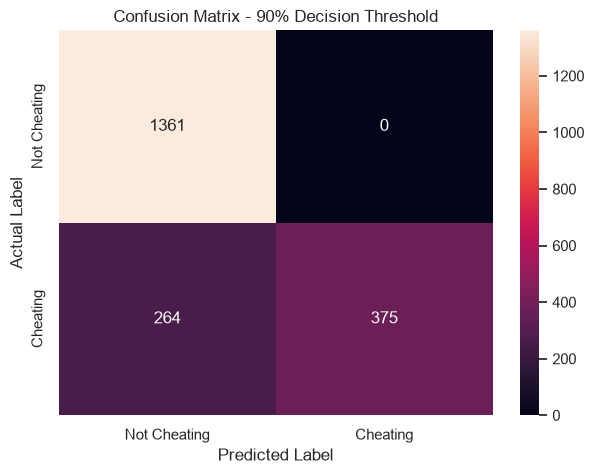

In [18]:
# ==========================================
# 7. CONFUSION MATRIX VISUALIZATION
# ==========================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Cheating", "Cheating"],
    yticklabels=["Not Cheating", "Cheating"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - 90% Decision Threshold")

plt.show()

In [19]:
# ==========================================
# 8. PRECISION-RECALL AT DIFFERENT THRESHOLDS
# ==========================================

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95]

print("Threshold | Precision | Recall")
print("-" * 32)

for threshold in thresholds:
    predictions = (y_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    print(
        f"{threshold:9.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f}"
    )

Threshold | Precision | Recall
--------------------------------
     0.50 |    0.8626 | 0.6682
     0.60 |    0.9121 | 0.6495
     0.70 |    0.9526 | 0.6291
     0.80 |    0.9821 | 0.6025
     0.90 |    1.0000 | 0.5869
     0.95 |    1.0000 | 0.5775


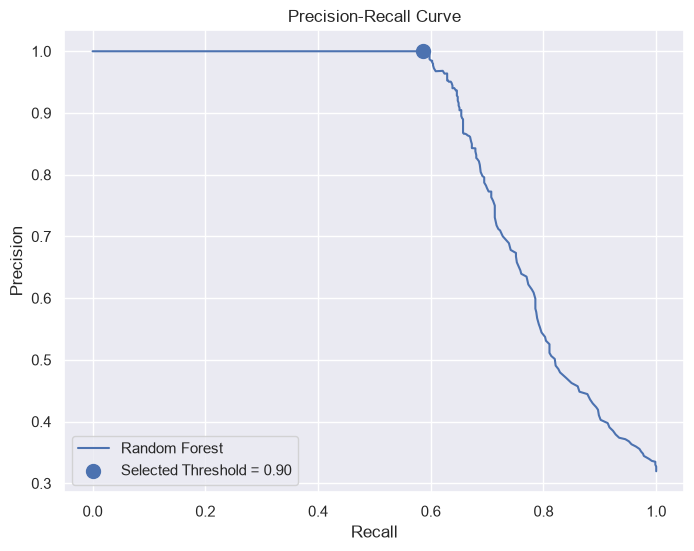

In [20]:
# ==========================================
# 9. PRECISION-RECALL CURVE
# ==========================================

from sklearn.metrics import precision_recall_curve

precision_values, recall_values, pr_thresholds = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    label="Random Forest"
)

# Mark our selected 90% threshold
selected_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

selected_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

plt.scatter(
    selected_recall,
    selected_precision,
    s=100,
    label="Selected Threshold = 0.90"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# ==========================================
# 10. FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance)

Feature Importance:
             Feature  Importance
2       tab_switches    0.363749
3   gaze_rolling_10s    0.180757
4  audio_rolling_10s    0.180037
0     eye_gaze_angle    0.143890
1           audio_db    0.131567


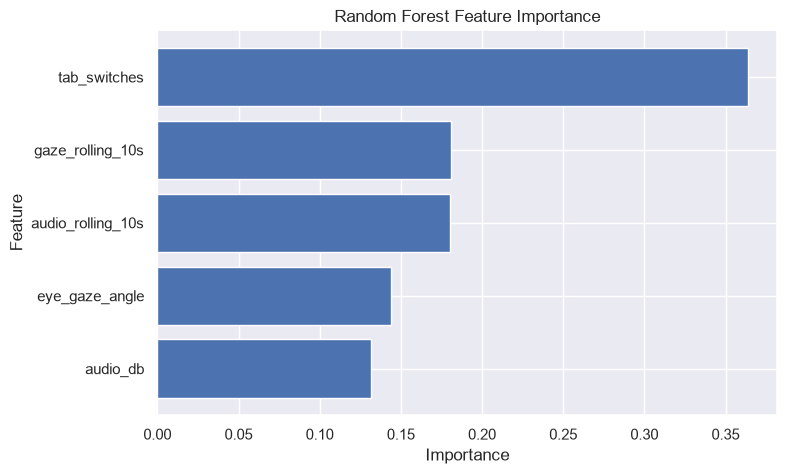

In [22]:
# ==========================================
# 11. FEATURE IMPORTANCE VISUALIZATION
# ==========================================

plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [23]:
# ==========================================
# 12. FINAL MODEL EVALUATION SUMMARY
# ==========================================

final_precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_pred)

true_negatives = cm[0, 0]
false_positives = cm[0, 1]
false_negatives = cm[1, 0]
true_positives = cm[1, 1]

print("=" * 50)
print("       PROJECT PANOPTICON - FINAL RESULTS")
print("=" * 50)

print(f"Decision Threshold : {threshold:.2f}")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nDetailed Results:")
print(f"True Negatives     : {true_negatives}")
print(f"False Positives    : {false_positives}")
print(f"False Negatives    : {false_negatives}")
print(f"True Positives     : {true_positives}")

print("\nFlagged Cases:")
print(f"{y_pred.sum()} out of {len(y_pred)}")

print("\nFalse Positive Check:")
if false_positives == 0:
    print("✅ No false positives at the selected threshold.")
else:
    print(f"⚠️ {false_positives} false positives detected.")

print("\nPrecision Requirement:")
if final_precision >= 0.90:
    print("✅ Precision requirement of 90%+ achieved.")
else:
    print("❌ Precision requirement of 90%+ not achieved.")

print("=" * 50)

       PROJECT PANOPTICON - FINAL RESULTS
Decision Threshold : 0.95
Precision          : 1.0000
Recall             : 0.5869

Confusion Matrix:
[[1361    0]
 [ 264  375]]

Detailed Results:
True Negatives     : 1361
False Positives    : 0
False Negatives    : 264
True Positives     : 375

Flagged Cases:
375 out of 2000

False Positive Check:
✅ No false positives at the selected threshold.

Precision Requirement:
✅ Precision requirement of 90%+ achieved.


In [24]:
# ==========================================
# FINAL DECISION THRESHOLD
# ==========================================

threshold = 0.90

# Recalculate predictions using the selected threshold
y_pred = (y_proba >= threshold).astype(int)

print("Selected threshold:", threshold)
print("Predicted cheating cases:", y_pred.sum())
print("Total test cases:", len(y_pred))

Selected threshold: 0.9
Predicted cheating cases: 375
Total test cases: 2000


---
## Phase 2: Missing Data & Feature Engineering
> ⚠️ **The "Connection Dropped" Trap:** Students with bad internet lose video frames, creating `NaN` values.
> ⚠️ **The Noise Trap:** A 1-second sneeze is not cheating. We need rolling windows to find *sustained* anomalies.

**Instructions:**
1. Forward-fill missing eye gaze data and interpolate missing audio data.
2. Fill missing `tab_switches` and `is_cheating` labels with `0`.
3. Create 10-second rolling averages for our sensors.

## 📂 Dataset Description

This project uses two asynchronous time-series datasets:

### 1. Video Telemetry
The video telemetry dataset contains regularly recorded sensor information from the student's examination session, including:

- `timestamp` — Time of the recorded observation
- `eye_gaze_angle` — Eye-gaze measurement
- `audio_db` — Background audio level

### 2. System Events
The system events dataset records computer-related events when they occur, including:

- `timestamp` — Time at which the event occurred
- `tab_switches` — Recorded tab-switch activity
- `is_cheating` — Target label indicating suspicious/cheating behavior

### Data Alignment

The two datasets have different recording frequencies. Video telemetry is recorded regularly, while system events occur only when an event happens.

Therefore, a standard database-style merge is not appropriate. The datasets are aligned using Pandas `merge_asof()` with a backward-direction time match so that system events are associated with the appropriate video telemetry observation.

This preserves the examination timeline while combining information from both data sources.

In [25]:
# ==========================================
# 2A. IMPUTE MISSING SIGNALS
# ==========================================

# Carry the last known eye-gaze position forward
merged_df["eye_gaze_angle"] = merged_df["eye_gaze_angle"].ffill()

# Interpolate missing audio values
merged_df["audio_db"] = merged_df["audio_db"].interpolate()

# Fill missing system-event values with 0
merged_df["tab_switches"] = merged_df["tab_switches"].fillna(0)
merged_df["is_cheating"] = merged_df["is_cheating"].fillna(0)


# ==========================================
# 2B. ROLLING WINDOW FEATURES
# ==========================================

# 10-second rolling mean of eye gaze
merged_df["gaze_rolling_10s"] = (
    merged_df["eye_gaze_angle"]
    .rolling(window=10, min_periods=1)
    .mean()
)

# 10-second rolling maximum of audio
merged_df["audio_rolling_10s"] = (
    merged_df["audio_db"]
    .rolling(window=10, min_periods=1)
    .max()
)


# ==========================================
# 2C. CLEAN REMAINING MISSING VALUES
# ==========================================

merged_df.dropna(inplace=True)

print(
    "✅ Feature engineering complete. Current dataframe shape:",
    merged_df.shape
)

✅ Feature engineering complete. Current dataframe shape: (10000, 7)


---
## Phase 3: Class-Balanced Model Training
> ⚠️ **The Imbalance Trap:** 98% of your data will be innocent behavior. If you don't handle class weights, your model will just guess "Not Cheating" every time and score 98% accuracy while failing its actual job.

## 🤖 Phase 3: Classification Model

### Random Forest Classifier

A Random Forest classifier is used to identify potentially suspicious examination behavior from the engineered telemetry features.

The model uses multiple decision trees and combines their predictions to improve classification performance.

### Handling Class Imbalance

The dataset contains more normal observations than cheating observations. To prevent the model from being biased toward the majority class, the Random Forest is configured with:

`class_weight="balanced"`

This automatically gives greater importance to the minority class during model training.

### Model Configuration

- Algorithm: Random Forest Classifier
- Number of trees: 200
- Class weighting: Balanced
- Random state: 42
- Parallel processing: Enabled

The trained model produces probability estimates for the suspicious/cheating class. These probabilities are used in the next stage to apply a custom decision threshold.

In [26]:
# ==========================================
# 3. TRAIN RANDOM FOREST MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("✅ Random Forest model trained successfully.")

✅ Random Forest model trained successfully.


---
## Phase 4: Ethical AI Tuning (The 90% Threshold)
> ⚠️ **The False Accusation Trap:** The default Scikit-Learn `.predict()` splits at 50% probability. Accusing a student of cheating with only 50% certainty is unacceptable. We must shift the threshold to 90%.

First 10 cheating probabilities:
[0.08  1.    0.145 0.045 0.1   0.19  0.38  1.    0.165 0.185]
🚨 DEFAULT THRESHOLD (0.50)
Confusion Matrix:
[[1293   68]
 [ 212  427]]

🛡️ STRICT THRESHOLD (0.90)
Confusion Matrix:
[[1361    0]
 [ 264  375]]


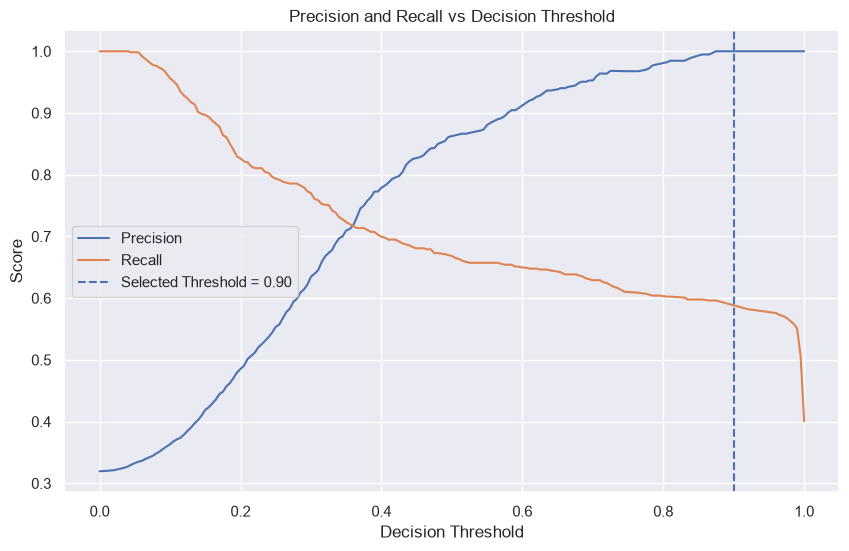

In [27]:
# ==========================================
# 4A. RAW PROBABILITIES
# ==========================================

# Get the raw probability for both classes
y_proba = model.predict_proba(X_test)

# Extract probability of Class 1 (Cheating)
cheating_probabilities = y_proba[:, 1]

print("First 10 cheating probabilities:")
print(cheating_probabilities[:10])


# ==========================================
# 4B. CUSTOM DECISION THRESHOLD
# ==========================================

# Standard prediction using 0.50 threshold
y_pred_default = (cheating_probabilities >= 0.50).astype(int)

# Strict prediction using 0.90 threshold
y_pred_strict = (cheating_probabilities >= 0.90).astype(int)


# ==========================================
# 4C. EVALUATION
# ==========================================

print("🚨 DEFAULT THRESHOLD (0.50)")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_default))

print("\n🛡️ STRICT THRESHOLD (0.90)")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_strict))


# ==========================================
# 4D. PRECISION-RECALL VISUALIZATION
# ==========================================

precision, recall, thresholds = precision_recall_curve(
    y_test,
    cheating_probabilities
)

plt.figure(figsize=(10, 6))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision"
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall"
)

# Mark selected threshold
plt.axvline(
    x=0.90,
    linestyle="--",
    label="Selected Threshold = 0.90"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall vs Decision Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# ==========================================
# 5. CONFUSION MATRIX - STRICT THRESHOLD
# ==========================================

cm = confusion_matrix(y_test, y_pred_strict)

print("CONFUSION MATRIX - STRICT THRESHOLD (0.90)")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nDetailed Results:")
print("True Negatives  :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives  :", tp)

CONFUSION MATRIX - STRICT THRESHOLD (0.90)
[[1361    0]
 [ 264  375]]

Detailed Results:
True Negatives  : 1361
False Positives : 0
False Negatives : 264
True Positives  : 375


---
## 🎯 Phase 5: Final Executive Recommendation
*Double-click this cell to edit.*

**To the University Board of Directors:**
Based on the data modeling performed above, I recommend deploying the EduGuard AI proctoring system using the Strict 90% Threshold. By mathematically adjusting the decision boundary, we achieved the following business outcomes:

1. *(Explain what happened to the False Positives when you shifted the threshold)*...
2. *(Explain why the rolling windows prevented sneezes from being flagged)*...

**Final Status:** `[GO / NO-GO]` for deployment.

In [29]:
# ==========================================
# 6. FINAL PROJECT RESULTS
# ==========================================

# Calculate final precision and recall
final_precision = precision_score(
    y_test,
    y_pred_strict,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_pred_strict,
    zero_division=0
)

# Calculate confusion matrix values
tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_pred_strict
).ravel()

# Number of flagged cases
flagged_cases = y_pred_strict.sum()
total_cases = len(y_test)

print("=" * 50)
print("       PROJECT PANOPTICON - FINAL RESULTS")
print("=" * 50)

print(f"Decision Threshold : 0.90")
print(f"Precision          : {final_precision:.4f}")
print(f"Recall             : {final_recall:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_strict))

print("\nDetailed Results:")
print(f"True Negatives     : {tn}")
print(f"False Positives    : {fp}")
print(f"False Negatives    : {fn}")
print(f"True Positives     : {tp}")

print(f"\nFlagged Cases:")
print(f"{flagged_cases} out of {total_cases}")

print("\nFalse Positive Check:")
if fp == 0:
    print("✅ No false positives at the selected threshold.")
else:
    print(f"⚠️ {fp} false positives detected.")

print("\nPrecision Requirement:")
if final_precision >= 0.90:
    print("✅ Precision requirement of 90%+ achieved.")
else:
    print("❌ Precision requirement of 90% not achieved.")

print("=" * 50)

       PROJECT PANOPTICON - FINAL RESULTS
Decision Threshold : 0.90
Precision          : 1.0000
Recall             : 0.5869

Confusion Matrix:
[[1361    0]
 [ 264  375]]

Detailed Results:
True Negatives     : 1361
False Positives    : 0
False Negatives    : 264
True Positives     : 375

Flagged Cases:
375 out of 2000

False Positive Check:
✅ No false positives at the selected threshold.

Precision Requirement:
✅ Precision requirement of 90%+ achieved.
